Sprint 2

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#connects to our shared google drive folder that has the csv. Professor I have added you to the shared drive so you can run the code
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/Shareddrives/CS122 Group 12/train.csv'
df= pd.read_csv(path)
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
df = df.dropna()
print(df.head())
df.isnull().sum()

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
#Determine popularity columns range
print(df['popularity'].min())
print(df['popularity'].max())

0
100


In [ ]:
#Create a row based off different ranges of popularity to assign a general ranking for later data analysis use
#Ranges include Popular: 100 - 70, Average: 69 - 40, Unpopular: 39-0
#Feel free to expand on this later if we need more robust categories

def pop_assign(score):
  if score >= 70:
    return 'Popular'
  elif score >= 40:
    return 'Average'
  else:
    return 'Unpopular'

#changing the column names
#popularity rating is now the raw popularity score
df = df.rename(columns={'popularity': 'popularity rating'})

#popularity will not be the column for the assigned values
df['popularity'] = df['popularity rating'].map(pop_assign)
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity rating,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,Popular
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,Average
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,Average
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,Popular
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,Popular


In [ ]:
df = df[df['popularity rating'] != 0]  # drop columns where popularity rating is 0

features_to_keep = [
    'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
    'track_genre'
]
prediction_feature = 'popularity rating'

X_unprocessed = df[features_to_keep]
y = df[prediction_feature]

X_unprocessed.dtypes  # from the output, need to change explicit (bool to int) and track_genre (one hot encoding for categorical variable)


,0
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64
speechiness,float64
acousticness,float64
instrumentalness,float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['track_genre']
binary_cols = ['explicit']
numeric_cols = [col for col in X_unprocessed.columns if col not in categorical_cols + binary_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('bin', 'passthrough', binary_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

X = preprocessor.fit_transform(X_unprocessed)
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1380162 stored elements and shape (97980, 128)>

# Visualizations


In [ ]:
#df.groupby('track_genre')[['duration_ms','explicit','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature','track_genre']]
#'duration_ms','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature'

# Filter the data to find each numerical feature for each genre
group = df.groupby('track_genre')[['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','time_signature']].mean()
print(group.index)

# Return genre to the dataframe instead of having it as a index
group = group.reset_index()

# Changes the dataframe so that it is usable by the catplot. Groups each column other than 'track_genre' and matches their value to another column
melted = group.melt(id_vars = 'track_genre', var_name = 'song_feature', value_name = 'values')

# Graphs all aspects of a song by genre and displays the information in a bar format
sns.catplot(
    data = melted,
    kind = 'bar',
    x = 'song_feature',
    y = 'values',
    col = 'track_genre',
    col_wrap = 3,
    aspect = 2.2,
    height = 5
)


Index(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime',
       'black-metal', 'bluegrass', 'blues', 'brazil',
       ...
       'spanish', 'study', 'swedish', 'synth-pop', 'tango', 'techno', 'trance',
       'trip-hop', 'turkish', 'world-music'],
      dtype='object', name='track_genre', length=114)


               duration_ms
track_genre               
acoustic     215282.638771
afrobeat     246796.487310
alt-rock     237588.324117
alternative  225657.091262
ambient      236157.777897


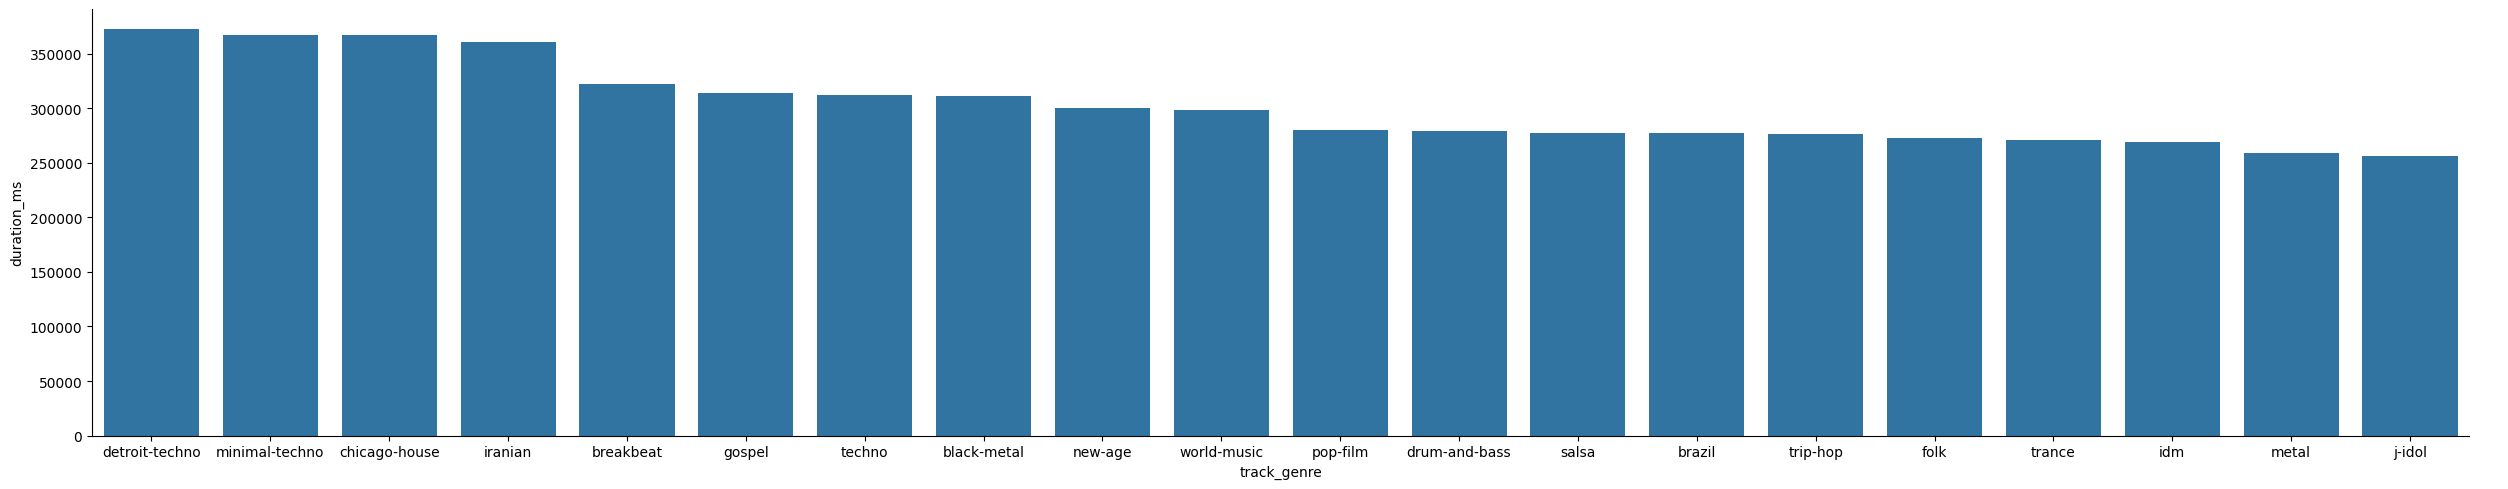

In [ ]:
# filters the data to give the average duration of a song in each genre
group = df.groupby('track_genre')[['duration_ms']].mean()
print(group.head())

# Groups and orders the genres by song length and retrieving the top 20 highest
group = group.sort_values(by='duration_ms', ascending = False).head(20)

# The catplot uses kind bar to display the duration length in decending order
sns.catplot(
    data = group,
    x = 'track_genre',
    y = 'duration_ms',
    kind = 'bar',
    aspect = 5
)

                  tempo
track_genre            
acoustic     118.842088
afrobeat     119.028400
alt-rock     124.456452
alternative  121.515010
ambient      111.268734


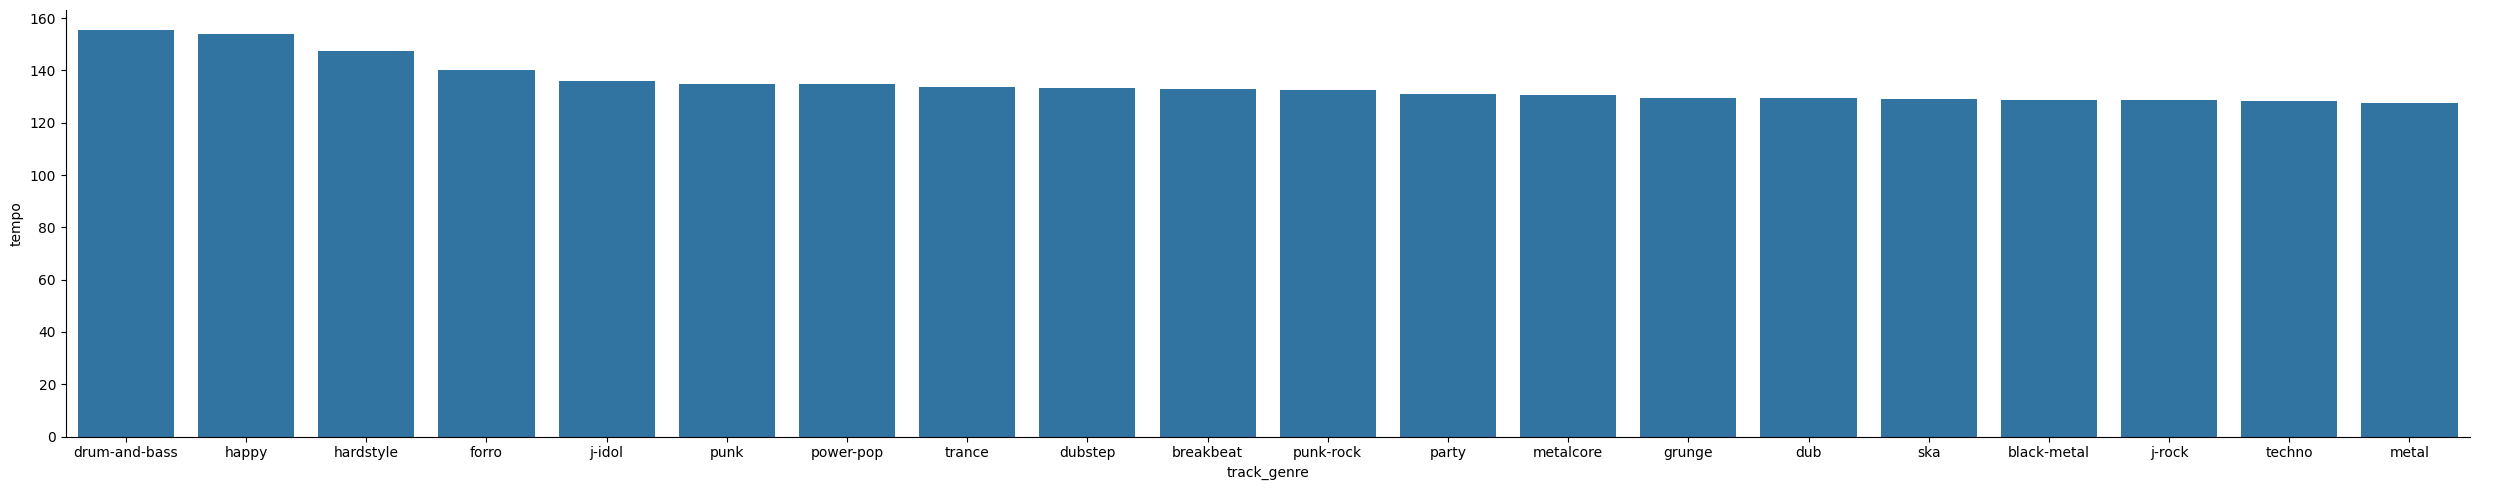

In [ ]:
# filters the data to give the average tempo of a song in each genre
group = df.groupby('track_genre')[['tempo']].mean()
print(group.head())

# Groups and orders the genres by tempo and retrieving the top 20 highest
group = group.sort_values(by='tempo', ascending = False).head(20)

# The catplot uses kind bar to display the tempo in decending order
sns.catplot(
    data = group,
    x = 'track_genre',
    y = 'tempo',
    kind = 'bar',
    aspect = 5
)

             popularity rating
track_genre                   
acoustic             45.003178
afrobeat             24.770558
alt-rock             52.139785
alternative          47.256311
ambient              47.415236


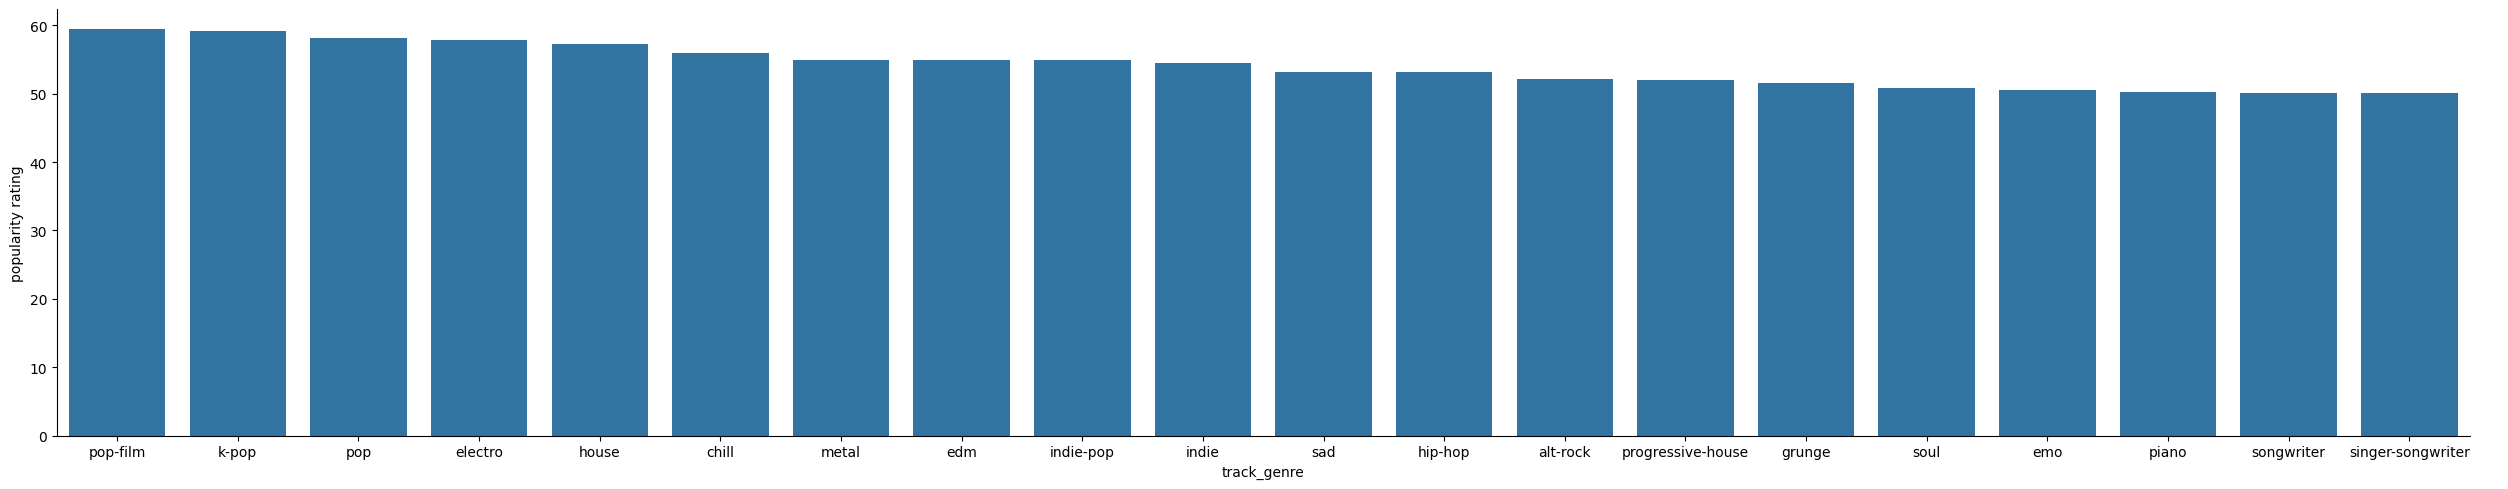

In [ ]:
# filters the data to give the average popularity of a song in each genre
group = df.groupby('track_genre')[['popularity rating']].mean()
print(group.head())

# Groups and orders the genres by popularity rating and retrieving the top 20 highest
group = group.sort_values(by='popularity rating', ascending = False).head(20)

#The catplot uses kind bar to display the popularity rating in decending order
sns.catplot(
    data = group,
    x = 'track_genre',
    y = 'popularity rating',
    kind = 'bar',
    aspect = 5
)

Text(0.5, 1.0, 'Spotify Music Attribute Correlation Heatmap')

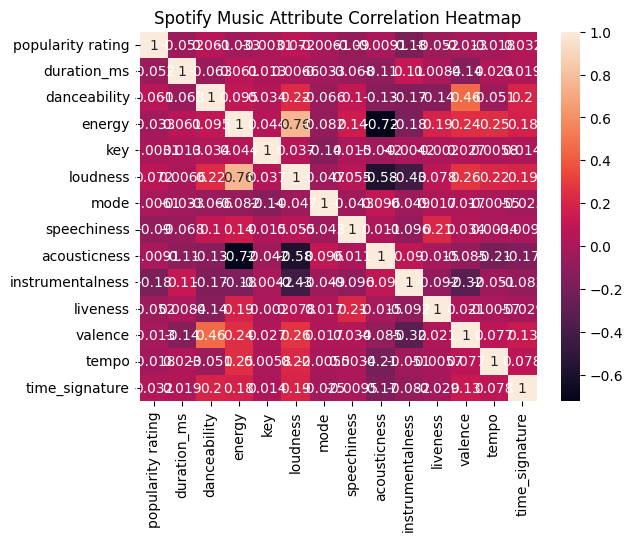

In [ ]:
# filters all numberical and wanted features to be used in a correlation matrix. .corr() is then used to create a correlation matrix
df_corr = df[['popularity rating','duration_ms','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']].corr()
df_corr.head()

# heatmap is used to display the correlation matrix and help visualize correlation. Annot = true is used to display the correlation values
sns.heatmap(df_corr, annot=True)
plt.title('Spotify Music Attribute Correlation Heatmap')

<Axes: xlabel='energy', ylabel='loudness'>

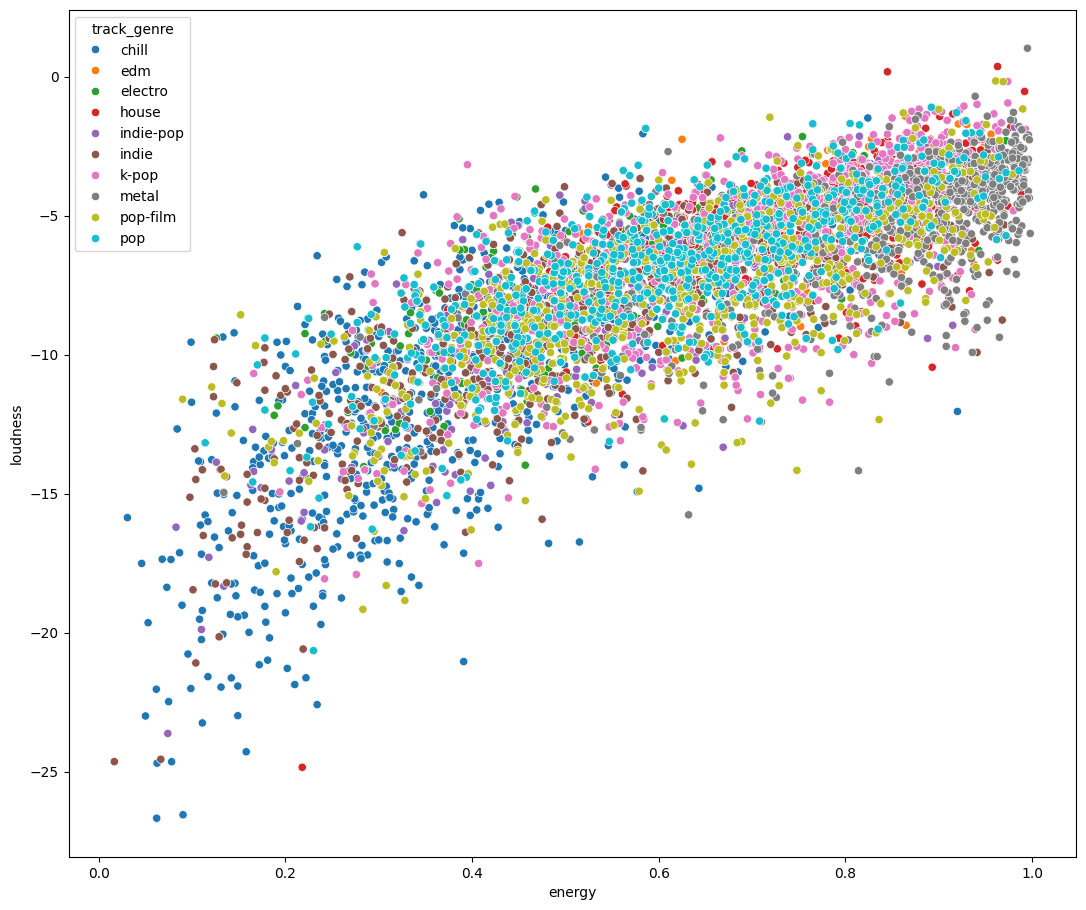

In [ ]:
#Based on the information from the heatmap I will be checking energy and loudness against popularity rating, and dancability and valence against popularity rating

# find the top genres based off average popularity rating
group = df.groupby('track_genre')[['popularity rating']].mean()
group = group.sort_values(by='popularity rating', ascending = False).head(10)
group = group.reset_index()

# create a df using only the rows that satisfy the top genres
top_genres = group['track_genre'].tolist()
top_songs = df[df['track_genre'].isin(top_genres)]
plt.figure(figsize=(13,11))

# graph the top 10 genres against energy and loudness which had a correlation value of 0.58
sns.scatterplot(data = top_songs, x = 'energy', y = 'loudness', hue = 'track_genre')

<Axes: xlabel='danceability', ylabel='valence'>

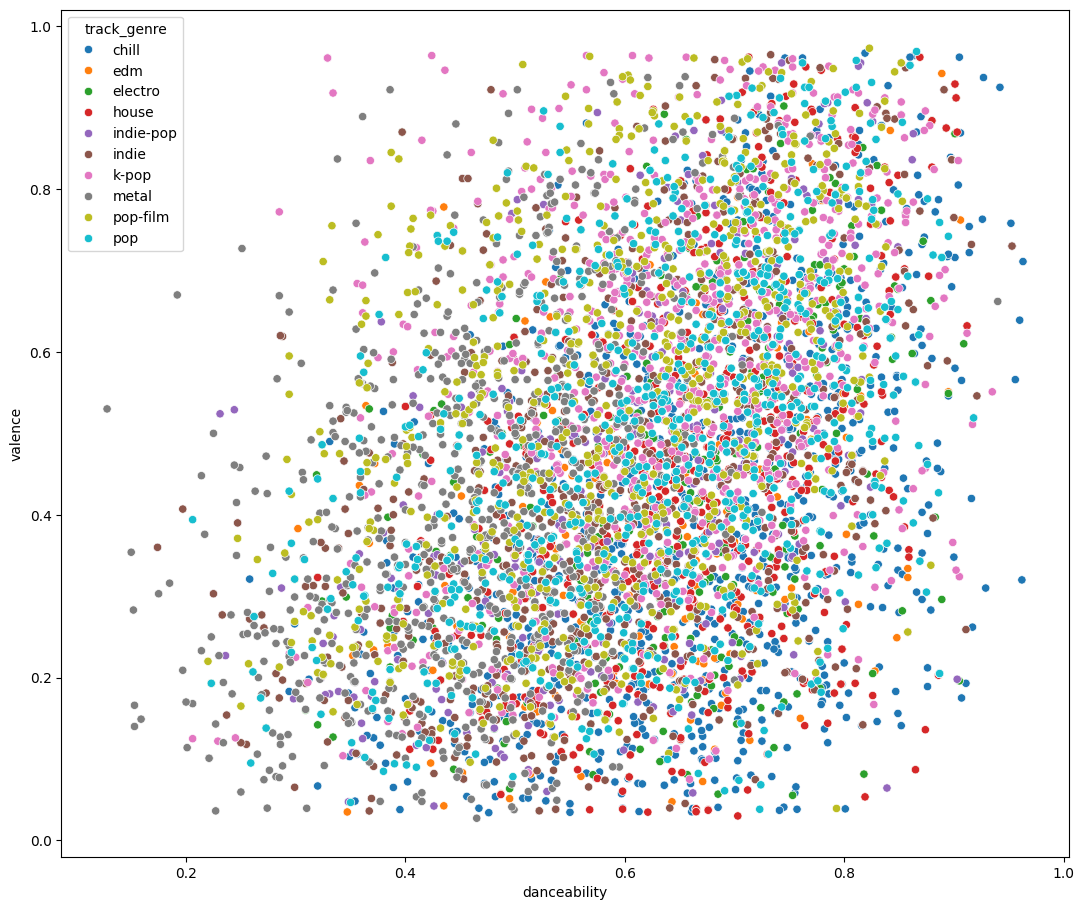

In [ ]:
# graph the top 10 genres against danceability and valence which had a correlation value of 0.46
plt.figure(figsize=(13,11))
sns.scatterplot(data = top_songs, x = 'danceability', y = 'valence', hue = 'track_genre')